# FinRL-DeepSeek for Stock Trading — Clean RL Protocol on FNSPID

**Goal.** Reproduce the clean FNSPID price/news pipeline, but replace the original CNN forecasting experiment with **reinforcement-learning trading agents**.

This notebook is intentionally **without world model**.

It implements:

1. loading FNSPID integrated price/news files or a prebuilt `panel_features_final.csv`;
2. point-in-time price and sentiment features;
3. LLM-news proxy features derived from GPT/FNSPID sentiment;
4. single-stock RL experiments, close to the original FNSPID protocol;
5. strictly filtered multi-stock portfolio experiments;
6. PPO/A2C training with Stable-Baselines3;
7. Buy & Hold and Equal Weight baselines;
8. financial metrics and paper-ready exports.

Main variants:

- `price_only`: market features only;
- `sentiment`: market features + GPT/FNSPID sentiment;
- `llm_news_proxy`: sentiment plus structured proxy variables derived from GPT/FNSPID sentiment.

## 0. Optional installation

Run this cell only if your environment does not already have the packages.

In [1]:
# Uncomment if needed.
# !pip install -q stable-baselines3 gymnasium optuna

## 1. Imports and global configuration

In [2]:
import os
import json
import math
import random
import warnings
from pathlib import Path
from typing import Dict, List, Tuple, Optional, Any

# Keep TensorFlow/TensorBoard noise low. Stable-Baselines3 uses PyTorch.
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")
os.environ.setdefault("TENSORBOARDX_NO_TF", "1")

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import torch
except Exception as e:
    raise ImportError("PyTorch is required. Install a CUDA-enabled PyTorch build if you want GPU training.") from e

try:
    import gymnasium as gym
    from gymnasium import spaces
except Exception as e:
    raise ImportError("gymnasium is required. Install with: pip install gymnasium") from e

try:
    from stable_baselines3 import PPO, A2C
    from stable_baselines3.common.monitor import Monitor
except Exception as e:
    raise ImportError("stable-baselines3 is required. Install with: pip install stable-baselines3") from e


def resolve_torch_device(device_preference: str = "auto") -> str:
    """
    Returns the device used by Stable-Baselines3.

    device_preference:
    - "auto": use CUDA if PyTorch detects it, otherwise CPU
    - "cuda": force CUDA and raise an error if unavailable
    - "cpu": force CPU
    - "cuda:0", "cuda:1", ...: force a specific CUDA device
    """
    preference = str(device_preference).lower().strip()

    if preference == "auto":
        return "cuda" if torch.cuda.is_available() else "cpu"

    if preference == "cpu":
        return "cpu"

    if preference.startswith("cuda"):
        if not torch.cuda.is_available():
            raise RuntimeError(
                "CUDA was requested but PyTorch cannot access a CUDA GPU. "
                "Install a CUDA-enabled PyTorch build or set CFG['device'] = 'cpu'."
            )
        return preference

    raise ValueError("CFG['device'] must be one of: 'auto', 'cpu', 'cuda', 'cuda:0', ...")


def print_compute_device_info(device_preference: str = "auto") -> str:
    selected_device = resolve_torch_device(device_preference)

    print("PyTorch version:", torch.__version__)
    print("CUDA available:", torch.cuda.is_available())
    print("Requested device:", device_preference)
    print("Selected SB3/PyTorch device:", selected_device)

    if torch.cuda.is_available():
        current_idx = torch.cuda.current_device()
        print("CUDA version used by PyTorch:", torch.version.cuda)
        print("GPU:", torch.cuda.get_device_name(current_idx))
        print("GPU count:", torch.cuda.device_count())
        try:
            free_bytes, total_bytes = torch.cuda.mem_get_info(current_idx)
            print(f"GPU memory free/total: {free_bytes / 1e9:.2f} GB / {total_bytes / 1e9:.2f} GB")
        except Exception:
            pass
    else:
        print("No CUDA GPU detected by PyTorch. Training will run on CPU.")

    return selected_device


def set_global_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_global_seed(42)
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 200)


In [3]:
# =========================
# CONFIGURATION
# =========================

CFG = {
    # Data source:
    # The original FNSPID experiments use one CSV per ticker, not a prebuilt panel CSV.
    # Therefore, by default we do NOT require panel_features_final.csv.
    "panel_csv": None,

    # Relative path matching the tree you shared:
    # financial-data/FNSPID_Financial_News_Dataset/dataset_test/CNN-for-Time-Series-Prediction/data/
    # If this relative path does not work, set the absolute Windows path manually, e.g.
    # r"C:\Users\utilisateur\Documents\AIVANCITY\AI for Finance\world model finance\financial-data\FNSPID_Financial_News_Dataset\dataset_test\CNN-for-Time-Series-Prediction\data"
    "integrated_dir": "financial-data/FNSPID_Financial_News_Dataset/dataset_test/CNN-for-Time-Series-Prediction/data",

    # If integrated_dir is not found, the notebook will search common FNSPID data folders automatically.
    "auto_detect_data_dir": True,

    "output_dir": "outputs/finrl_deepseek_clean_rl",

    # Compute device for Stable-Baselines3 / PyTorch.
    # "auto" uses CUDA when available, otherwise CPU. Use "cuda" to force GPU and fail if unavailable.
    "device": "auto",

    # "debug" is fast; "paper" is intended for final results.
    # Start with debug to check the full pipeline, then switch to paper for final experiments.
    "run_profile": "paper",
    "timesteps_debug": 5_000,
    "timesteps_paper": 50_000,

    "train_test_split": 0.85,
    "min_test_days_single": 80,
    "min_test_days_multi": 150,

    # Tickers used in the original FNSPID benchmark outputs and present in the dataset_test data folder.
    "single_stock_tickers": ["AMD", "GOOG", "KO", "TSM", "WMT"],

    # Multi-stock is stricter because it requires common trading dates.
    "multi_stock_tickers": ["AMD", "GOOG", "KO", "TSM", "WMT"],

    "feature_sets": ["price_only", "sentiment", "llm_news_proxy"],
    "rl_algorithms": ["PPO", "A2C"],

    "initial_amount": 1_000_000.0,
    "transaction_cost_pct": 0.001,
    "reward_scaling": 1.0,
    "risk_penalty": 0.0,

    "clip_features": 10.0,
    "seed": 42,
    "skip_existing_models": False,
    "save_models": True,
}

CFG["rl_total_timesteps"] = CFG["timesteps_debug"] if CFG["run_profile"] == "debug" else CFG["timesteps_paper"]
CFG["device_resolved"] = print_compute_device_info(CFG.get("device", "auto"))

OUT = Path(CFG["output_dir"])
for sub in ["models", "tables", "figures", "equity_curves", "weights", "panels"]:
    (OUT / sub).mkdir(parents=True, exist_ok=True)

print(json.dumps(CFG, indent=2))


PyTorch version: 2.5.1+cu121
CUDA available: True
Requested device: auto
Selected SB3/PyTorch device: cuda
CUDA version used by PyTorch: 12.1
GPU: NVIDIA GeForce RTX 4060 Laptop GPU
GPU count: 1
GPU memory free/total: 7.45 GB / 8.59 GB
{
  "panel_csv": null,
  "integrated_dir": "financial-data/FNSPID_Financial_News_Dataset/dataset_test/CNN-for-Time-Series-Prediction/data",
  "auto_detect_data_dir": true,
  "output_dir": "outputs/finrl_deepseek_clean_rl",
  "device": "auto",
  "run_profile": "paper",
  "timesteps_debug": 5000,
  "timesteps_paper": 50000,
  "train_test_split": 0.85,
  "min_test_days_single": 80,
  "min_test_days_multi": 150,
  "single_stock_tickers": [
    "AMD",
    "GOOG",
    "KO",
    "TSM",
    "WMT"
  ],
  "multi_stock_tickers": [
    "AMD",
    "GOOG",
    "KO",
    "TSM",
    "WMT"
  ],
  "feature_sets": [
    "price_only",
    "sentiment",
    "llm_news_proxy"
  ],
  "rl_algorithms": [
    "PPO",
    "A2C"
  ],
  "initial_amount": 1000000.0,
  "transaction_cost_

## 2. Data loading

The notebook supports two modes.

**Recommended mode — original FNSPID per-ticker CSV files**

This matches the author's experimental protocol: one CSV per ticker, for example `AMD.csv`, `GOOG.csv`, `KO.csv`, etc.

The default path now follows your local tree:

```text
financial-data/FNSPID_Financial_News_Dataset/dataset_test/CNN-for-Time-Series-Prediction/data
```

If that relative path does not work, set `CFG["integrated_dir"]` to the absolute Windows path.

Expected columns are standardized automatically:

- `Date`, `Open`, `High`, `Low`, `Close`, `Volume`
- `Sentiment_gpt`
- `Scaled_sentiment`
- `News_flag`

**Optional mode — prebuilt panel**

You may still use a cached panel such as `panel_features_final.csv`, but it is no longer required. Set `CFG["panel_csv"]` only if the file exists.


In [4]:
def resolve_path(path_like: Optional[str]) -> Optional[Path]:
    """
    Resolve a file/folder path robustly across:
    - absolute paths;
    - paths relative to the notebook working directory;
    - paths relative to parent directories;
    - Kaggle and /mnt/data fallbacks.
    """
    if path_like is None:
        return None

    p = Path(path_like).expanduser()

    candidates = []
    if p.is_absolute():
        candidates.append(p)
    else:
        candidates.extend([
            Path.cwd() / p,
            Path.cwd().parent / p,
            Path.cwd().parent.parent / p,
            Path("/mnt/data") / p,
            Path("/mnt/data") / p.name,
            Path("/kaggle/working") / p,
            Path("/kaggle/input") / p,
        ])

    candidates.append(p)

    # Also test the path relative to every parent of the current directory.
    for parent in [Path.cwd(), *Path.cwd().parents]:
        candidates.append(parent / p)

    seen = set()
    for c in candidates:
        c = c.resolve() if c.exists() else c
        if str(c) in seen:
            continue
        seen.add(str(c))
        if c.exists():
            return c

    return p


def candidate_fns_pid_data_dirs() -> List[Path]:
    """
    Candidate folders containing one CSV per ticker, matching the FNSPID repository structure.
    The first candidates match the arborescence shared in the conversation.
    """
    rel_candidates = [
        Path("financial-data/FNSPID_Financial_News_Dataset/dataset_test/CNN-for-Time-Series-Prediction/data"),
        Path("financial-data/FNSPID_Financial_News_Dataset/dataset_test/LSTM-for-Time-Series-Prediction/data"),
        Path("financial-data/FNSPID_Financial_News_Dataset/dataset_test/GRU-for-Time-Series-Prediction/data"),
        Path("financial-data/FNSPID_Financial_News_Dataset/dataset_test/Transformer-for-Time-Series-Prediction/data"),
        Path("FNSPID_Financial_News_Dataset/dataset_test/CNN-for-Time-Series-Prediction/data"),
        Path("FNSPID_Financial_News_Dataset/dataset_test/LSTM-for-Time-Series-Prediction/data"),
        Path("FNSPID_Financial_News_Dataset/dataset_test/GRU-for-Time-Series-Prediction/data"),
        Path("FNSPID_Financial_News_Dataset/dataset_test/Transformer-for-Time-Series-Prediction/data"),
        Path("dataset_test/CNN-for-Time-Series-Prediction/data"),
        Path("dataset_test/LSTM-for-Time-Series-Prediction/data"),
        Path("dataset_test/GRU-for-Time-Series-Prediction/data"),
        Path("dataset_test/Transformer-for-Time-Series-Prediction/data"),
        Path("data_processor/gpt_sentiment_price_news_integrate"),
        Path("gpt_sentiment_price_news_integrate"),
        Path("data"),
    ]

    roots = [Path.cwd(), *Path.cwd().parents, Path("/mnt/data"), Path("/kaggle/input"), Path("/kaggle/working")]
    candidates = []

    for root in roots:
        for rel in rel_candidates:
            candidates.append(root / rel)

    # Remove duplicates while preserving order.
    out, seen = [], set()
    for c in candidates:
        s = str(c)
        if s not in seen:
            seen.add(s)
            out.append(c)

    return out


def has_ticker_csvs(data_dir: Path, tickers: Optional[List[str]] = None) -> bool:
    if not data_dir.exists() or not data_dir.is_dir():
        return False

    csvs = list(data_dir.glob("*.csv"))
    if not csvs:
        return False

    if not tickers:
        return True

    available = {p.stem.upper() for p in csvs}
    wanted = {t.upper() for t in tickers}
    return len(available.intersection(wanted)) > 0


def auto_detect_integrated_dir(tickers: Optional[List[str]] = None) -> Path:
    for candidate in candidate_fns_pid_data_dirs():
        if has_ticker_csvs(candidate, tickers=tickers):
            return candidate

    searched = "\n".join(str(p) for p in candidate_fns_pid_data_dirs()[:20])
    raise FileNotFoundError(
        "Could not auto-detect a FNSPID data directory containing ticker CSV files.\n"
        "Set CFG['integrated_dir'] to an absolute path such as:\n"
        r"r'C:\...\financial-data\FNSPID_Financial_News_Dataset\dataset_test\CNN-for-Time-Series-Prediction\data'"
        "\n\nFirst searched locations:\n" + searched
    )


def standardize_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = (
        df.columns
        .str.strip()
        .str.replace(" ", "_", regex=False)
        .str.replace("-", "_", regex=False)
        .str.lower()
    )

    rename_map = {
        "datetime": "date",
        "stock": "tic",
        "ticker": "tic",
        "symbol": "tic",
        "adjclose": "adj_close",
        "adj_close": "adj_close",
        "newsflag": "news_flag",
        "sentiment": "sentiment_gpt",
        "sentimentgpt": "sentiment_gpt",
        "scaled_sentiment": "scaled_sentiment",
    }
    df = df.rename(columns={c: rename_map.get(c, c) for c in df.columns})

    if "date" not in df.columns:
        raise ValueError(f"No date column found. Columns: {df.columns.tolist()}")

    df["date"] = pd.to_datetime(df["date"], utc=True, errors="coerce").dt.tz_convert(None).dt.normalize()

    if "tic" in df.columns:
        df["tic"] = df["tic"].astype(str).str.upper()

    return df


def load_panel_csv(panel_csv: str) -> pd.DataFrame:
    p = resolve_path(panel_csv)
    if not p.exists():
        raise FileNotFoundError(f"Panel CSV not found: {panel_csv}. Resolved path: {p}")

    panel = pd.read_csv(p)
    panel = standardize_columns(panel)

    if "tic" not in panel.columns:
        raise ValueError("Prebuilt panel CSV must contain a tic/ticker/symbol column.")

    return panel


def load_integrated_fns_pid_dir(integrated_dir: str, tickers: Optional[List[str]] = None) -> pd.DataFrame:
    data_dir = resolve_path(integrated_dir)
    if data_dir is None or not data_dir.exists():
        raise FileNotFoundError(f"Integrated directory not found: {integrated_dir}. Resolved path: {data_dir}")

    tickers_upper = None if tickers is None else {t.upper() for t in tickers}
    rows = []
    missing_tickers = set() if tickers_upper is None else set(tickers_upper)

    csv_files = sorted(data_dir.glob("*.csv"))
    if not csv_files:
        raise FileNotFoundError(f"No CSV files found in: {data_dir}")

    for fp in csv_files:
        tic = fp.stem.upper()
        if tickers_upper is not None and tic not in tickers_upper:
            continue

        try:
            df = pd.read_csv(fp)
        except UnicodeDecodeError:
            df = pd.read_csv(fp, encoding="ISO-8859-1")

        df = standardize_columns(df)
        df["tic"] = tic
        rows.append(df)

        if tic in missing_tickers:
            missing_tickers.remove(tic)

    if not rows:
        available = sorted([p.stem.upper() for p in csv_files])[:50]
        raise ValueError(
            "No integrated CSV was loaded. Check tickers and path.\n"
            f"Data directory: {data_dir}\n"
            f"First available tickers: {available}"
        )

    if missing_tickers:
        print(f"Warning: missing requested tickers in {data_dir}: {sorted(missing_tickers)}")

    out = pd.concat(rows, ignore_index=True)
    print(f"Loaded {len(rows)} ticker CSV files from: {data_dir}")
    return out


def load_data_from_cfg(cfg: Dict[str, Any]) -> pd.DataFrame:
    wanted = sorted(set(cfg["single_stock_tickers"] + cfg["multi_stock_tickers"]))

    # Prefer a panel only if explicitly set AND found.
    # If it is missing, fall back to the original per-ticker FNSPID files instead of crashing.
    if cfg.get("panel_csv"):
        p = resolve_path(cfg["panel_csv"])
        if p.exists():
            print(f"Loading prebuilt panel: {p}")
            return load_panel_csv(str(p))
        print(f"Panel CSV not found ({cfg['panel_csv']}). Falling back to per-ticker FNSPID CSV files.")

    data_dir = None

    if cfg.get("integrated_dir"):
        p = resolve_path(cfg["integrated_dir"])
        if p is not None and p.exists():
            data_dir = p
        else:
            print(f"Configured integrated_dir not found: {cfg['integrated_dir']}")

    if data_dir is None and cfg.get("auto_detect_data_dir", True):
        data_dir = auto_detect_integrated_dir(tickers=wanted)
        print(f"Auto-detected integrated_dir: {data_dir}")

    if data_dir is not None:
        return load_integrated_fns_pid_dir(str(data_dir), tickers=wanted)

    raise ValueError("Set either CFG['panel_csv'] or CFG['integrated_dir'], or enable CFG['auto_detect_data_dir'].")


panel_raw = load_data_from_cfg(CFG)
print(panel_raw.shape)
display(panel_raw.head())
display(panel_raw.groupby("tic")["date"].agg(["min", "max", "count"]).sort_index())


Configured integrated_dir not found: financial-data/FNSPID_Financial_News_Dataset/dataset_test/CNN-for-Time-Series-Prediction/data
Auto-detected integrated_dir: c:\Users\utilisateur\Documents\AIVANCITY\AI for Finance\world model finance\FNSPID_Financial_News_Dataset\dataset_test\CNN-for-Time-Series-Prediction\data
Loaded 5 ticker CSV files from: C:\Users\utilisateur\Documents\AIVANCITY\AI for Finance\world model finance\FNSPID_Financial_News_Dataset\dataset_test\CNN-for-Time-Series-Prediction\data
(11277, 11)


,date,open,high,low,close,adj_close,volume,sentiment_gpt,news_flag,scaled_sentiment,tic
0,2016-12-12,10.40,10.93,10.38,10.68,10.68,63342900.0,2.600000,1.0,0.400025,AMD
1,2016-12-13,10.75,10.80,10.40,10.54,10.54,46967800.0,4.000000,1.0,0.750025,AMD
2,2016-12-14,10.43,10.74,10.27,10.55,10.55,46968600.0,4.000000,1.0,0.750025,AMD
3,2016-12-15,10.68,10.93,10.64,10.86,10.86,48871300.0,3.666667,1.0,0.666692,AMD
4,2016-12-16,10.94,11.23,10.60,10.66,10.66,77777700.0,4.000000,1.0,0.750025,AMD


,min,max,count
tic,,,
AMD,2016-12-12,2023-12-28,1773
GOOG,2019-02-06,2023-12-15,1225
KO,2009-10-14,2023-12-15,3568
TSM,2010-04-15,2023-12-15,3443
WMT,2018-12-03,2023-12-15,1268


## 3. Feature engineering

In [5]:
def ensure_required_market_columns(panel: pd.DataFrame) -> pd.DataFrame:
    panel = panel.copy()

    required = ["date", "tic", "close"]
    missing = [c for c in required if c not in panel.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    for c in ["open", "high", "low"]:
        if c not in panel.columns:
            panel[c] = panel["close"]

    if "volume" not in panel.columns:
        panel["volume"] = 0.0

    if "sentiment_gpt" not in panel.columns:
        if "scaled_sentiment" in panel.columns:
            panel["sentiment_gpt"] = panel["scaled_sentiment"] * 4.0 + 0.9999
        else:
            panel["sentiment_gpt"] = 3.0

    panel["sentiment_gpt"] = pd.to_numeric(panel["sentiment_gpt"], errors="coerce").fillna(3.0).clip(1.0, 5.0)

    if "scaled_sentiment" not in panel.columns:
        panel["scaled_sentiment"] = ((panel["sentiment_gpt"] - 0.9999) / 4.0).clip(0.0, 1.0)
    else:
        panel["scaled_sentiment"] = pd.to_numeric(panel["scaled_sentiment"], errors="coerce")
        fallback = ((panel["sentiment_gpt"] - 0.9999) / 4.0).clip(0.0, 1.0)
        panel["scaled_sentiment"] = panel["scaled_sentiment"].fillna(fallback).clip(0.0, 1.0)

    if "news_flag" not in panel.columns:
        panel["news_flag"] = (panel["sentiment_gpt"].round(6) != 3.0).astype(float)
    else:
        panel["news_flag"] = pd.to_numeric(panel["news_flag"], errors="coerce").fillna(0.0).clip(0.0, 1.0)

    if "news_count" not in panel.columns:
        panel["news_count"] = panel["news_flag"]
    else:
        panel["news_count"] = pd.to_numeric(panel["news_count"], errors="coerce").fillna(panel["news_flag"])

    for c in ["open", "high", "low", "close", "volume"]:
        panel[c] = pd.to_numeric(panel[c], errors="coerce")

    panel = panel.dropna(subset=["date", "tic", "close"])
    panel = panel.sort_values(["tic", "date"]).drop_duplicates(["tic", "date"], keep="last")
    return panel


def add_price_features(panel: pd.DataFrame) -> pd.DataFrame:
    panel = panel.copy().sort_values(["tic", "date"])
    g = panel.groupby("tic", group_keys=False)

    panel["return_1"] = g["close"].pct_change()
    panel["log_return"] = g["close"].transform(lambda s: np.log(s).diff())

    for w in [3, 5, 10]:
        panel[f"return_{w}"] = g["close"].pct_change(w)

    for w in [5, 10, 20]:
        panel[f"volatility_{w}"] = g["log_return"].transform(lambda s: s.rolling(w, min_periods=max(2, w // 2)).std())
        panel[f"ma_{w}"] = g["close"].transform(lambda s: s.rolling(w, min_periods=max(2, w // 2)).mean())
        panel[f"ma_ratio_{w}"] = panel["close"] / panel[f"ma_{w}"] - 1.0

    panel["volume_log"] = np.log1p(panel["volume"].clip(lower=0))
    panel["volume_z_20"] = g["volume_log"].transform(
        lambda s: (s - s.rolling(20, min_periods=5).mean()) / (s.rolling(20, min_periods=5).std() + 1e-8)
    )

    panel["hl_spread"] = (panel["high"] - panel["low"]) / panel["close"].replace(0, np.nan)
    panel["oc_return"] = (panel["close"] - panel["open"]) / panel["open"].replace(0, np.nan)

    return panel


def add_llm_proxy_features(panel: pd.DataFrame, alpha: float = 0.20) -> pd.DataFrame:
    """
    Build structured LLM-news proxy features from the GPT/FNSPID sentiment score.

    sentiment_gpt in [1, 5] is mapped to sentiment_score in [-1, 1].
    """
    panel = panel.copy().sort_values(["tic", "date"])

    panel["sentiment_score"] = ((panel["sentiment_gpt"] - 3.0) / 2.0).clip(-1.0, 1.0)

    panel["llm_sentiment"] = panel["sentiment_score"]
    panel["llm_relevance"] = np.where(panel["news_count"].fillna(0) > 0, 1.0, 0.5)
    panel["llm_risk"] = (-panel["sentiment_score"]).clip(0.0, 1.0)
    panel["llm_uncertainty"] = 1.0 - panel["sentiment_score"].abs()
    panel["llm_signal"] = panel["llm_sentiment"] * panel["llm_relevance"] * (1.0 - 0.5 * panel["llm_risk"])

    for col in ["sentiment_score", "llm_signal", "llm_risk", "llm_uncertainty"]:
        panel[f"{col}_decay"] = panel.groupby("tic")[col].transform(lambda s: s.ewm(alpha=alpha, adjust=False).mean())

    return panel


def finalize_panel(panel: pd.DataFrame) -> pd.DataFrame:
    panel = ensure_required_market_columns(panel)
    panel = add_price_features(panel)
    panel = add_llm_proxy_features(panel)
    panel = panel.replace([np.inf, -np.inf], np.nan)

    neutral_cols = [
        "return_1", "log_return", "return_3", "return_5", "return_10",
        "volatility_5", "volatility_10", "volatility_20",
        "ma_ratio_5", "ma_ratio_10", "ma_ratio_20",
        "volume_z_20", "hl_spread", "oc_return",
        "sentiment_score", "sentiment_score_decay",
        "llm_signal", "llm_signal_decay",
        "llm_risk", "llm_risk_decay",
        "llm_uncertainty", "llm_uncertainty_decay",
    ]

    for c in neutral_cols:
        if c in panel.columns:
            panel[c] = panel[c].fillna(0.0)

    panel["news_flag"] = panel["news_flag"].fillna(0.0)
    panel["news_count"] = panel["news_count"].fillna(0.0)

    return panel.sort_values(["tic", "date"]).reset_index(drop=True)


panel = finalize_panel(panel_raw)
panel_path = OUT / "panels" / "panel_features_clean_rl.csv"
panel.to_csv(panel_path, index=False)

print(f"Saved clean panel: {panel_path}")
print(panel.shape)
display(panel.head())

Saved clean panel: outputs\finrl_deepseek_clean_rl\panels\panel_features_clean_rl.csv
(11277, 40)


,date,open,high,low,close,adj_close,volume,sentiment_gpt,news_flag,scaled_sentiment,tic,news_count,return_1,log_return,return_3,return_5,return_10,volatility_5,ma_5,ma_ratio_5,volatility_10,ma_10,ma_ratio_10,volatility_20,ma_20,ma_ratio_20,volume_log,volume_z_20,hl_spread,oc_return,sentiment_score,llm_sentiment,llm_relevance,llm_risk,llm_uncertainty,llm_signal,sentiment_score_decay,llm_signal_decay,llm_risk_decay,llm_uncertainty_decay
0,2016-12-12,10.40,10.93,10.38,10.68,10.68,63342900.0,2.600000,1.0,0.400025,AMD,1.0,0.000000,0.000000,0.000000,0.0,0.0,0.000000,NaN,0.000000,0.0,NaN,0.000000,0.0,NaN,0.0,17.964073,0.000000,0.051498,0.026923,-0.200000,-0.200000,1.0,0.2,0.800000,-0.180000,-0.200000,-0.180000,0.20000,0.800000
1,2016-12-13,10.75,10.80,10.40,10.54,10.54,46967800.0,4.000000,1.0,0.750025,AMD,1.0,-0.013109,-0.013195,0.000000,0.0,0.0,0.000000,10.6100,-0.006598,0.0,NaN,0.000000,0.0,NaN,0.0,17.664973,0.000000,0.037951,-0.019535,0.500000,0.500000,1.0,0.0,0.500000,0.500000,-0.060000,-0.044000,0.16000,0.740000
2,2016-12-14,10.43,10.74,10.27,10.55,10.55,46968600.0,4.000000,1.0,0.750025,AMD,1.0,0.000949,0.000948,0.000000,0.0,0.0,0.010001,10.5900,-0.003777,0.0,NaN,0.000000,0.0,NaN,0.0,17.664990,0.000000,0.044550,0.011505,0.500000,0.500000,1.0,0.0,0.500000,0.500000,0.052000,0.064800,0.12800,0.692000
3,2016-12-15,10.68,10.93,10.64,10.86,10.86,48871300.0,3.666667,1.0,0.666692,AMD,1.0,0.029384,0.028960,0.016854,0.0,0.0,0.021455,10.6575,0.019001,0.0,NaN,0.000000,0.0,NaN,0.0,17.704701,0.000000,0.026703,0.016854,0.333333,0.333333,1.0,0.0,0.666667,0.333333,0.108267,0.118507,0.10240,0.686933
4,2016-12-16,10.94,11.23,10.60,10.66,10.66,77777700.0,4.000000,1.0,0.750025,AMD,1.0,-0.018416,-0.018588,0.011385,0.0,0.0,0.021279,10.6580,0.000188,0.0,10.658,0.000188,0.0,NaN,0.0,18.169365,1.489476,0.059099,-0.025594,0.500000,0.500000,1.0,0.0,0.500000,0.500000,0.186613,0.194805,0.08192,0.649547


In [6]:
print("Ticker date coverage:")
display(panel.groupby("tic")["date"].agg(["min", "max", "count"]).sort_index())

print("\nFeature activity checks:")
activity_cols = [
    "news_flag", "news_count", "sentiment_gpt", "scaled_sentiment",
    "sentiment_score", "sentiment_score_decay",
    "llm_signal", "llm_signal_decay",
    "llm_risk_decay", "llm_uncertainty_decay",
]
for col in activity_cols:
    if col in panel.columns:
        s = panel[col]
        print(f"{col:25s} | non-null={s.notna().sum():7d} | mean={s.mean(): .6f} | std={s.std(): .6f} | abs_sum={s.abs().sum(): .6f}")

if panel["llm_signal"].abs().sum() == 0:
    print("\nWARNING: llm_signal is zero everywhere. Check sentiment_gpt/scaled_sentiment.")
else:
    print("\nOK: LLM proxy features are active.")

Ticker date coverage:


,min,max,count
tic,,,
AMD,2016-12-12,2023-12-28,1773
GOOG,2019-02-06,2023-12-15,1225
KO,2009-10-14,2023-12-15,3568
TSM,2010-04-15,2023-12-15,3443
WMT,2018-12-03,2023-12-15,1268



Feature activity checks:
news_flag                 | non-null=  11277 | mean= 0.745677 | std= 0.435499 | abs_sum= 8409.000000
news_count                | non-null=  11277 | mean= 0.745677 | std= 0.435499 | abs_sum= 8409.000000
sentiment_gpt             | non-null=  11277 | mean= 3.277702 | std= 0.722919 | abs_sum= 36962.648276
scaled_sentiment          | non-null=  11277 | mean= 0.569450 | std= 0.180728 | abs_sum= 6421.686944
sentiment_score           | non-null=  11277 | mean= 0.138851 | std= 0.361460 | abs_sum= 3233.851296
sentiment_score_decay     | non-null=  11277 | mean= 0.137991 | std= 0.208769 | abs_sum= 2215.853741
llm_signal                | non-null=  11277 | mean= 0.141489 | std= 0.306911 | abs_sum= 2727.638696
llm_signal_decay          | non-null=  11277 | mean= 0.140682 | std= 0.170790 | abs_sum= 1925.895901
llm_risk_decay            | non-null=  11277 | mean= 0.074237 | std= 0.085161 | abs_sum= 837.169078
llm_uncertainty_decay     | non-null=  11277 | mean= 0.713535 | s

## 4. Feature sets

In [7]:
FEATURE_SETS = {
    "price_only": [
        "log_return",
        "return_3",
        "return_5",
        "return_10",
        "volatility_10",
        "ma_ratio_10",
        "volume_z_20",
        "hl_spread",
        "oc_return",
    ],
    "sentiment": [
        "log_return",
        "return_3",
        "return_5",
        "return_10",
        "volatility_10",
        "ma_ratio_10",
        "volume_z_20",
        "hl_spread",
        "oc_return",
        "scaled_sentiment",
        "sentiment_score_decay",
    ],
    "llm_news_proxy": [
        "log_return",
        "return_3",
        "return_5",
        "return_10",
        "volatility_10",
        "ma_ratio_10",
        "volume_z_20",
        "hl_spread",
        "oc_return",
        "scaled_sentiment",
        "sentiment_score_decay",
        "news_flag",
        "news_count",
        "llm_signal_decay",
        "llm_risk_decay",
        "llm_uncertainty_decay",
    ],
}

for k, cols in FEATURE_SETS.items():
    missing = [c for c in cols if c not in panel.columns]
    if missing:
        raise ValueError(f"Feature set {k} has missing columns: {missing}")

print(FEATURE_SETS)

{'price_only': ['log_return', 'return_3', 'return_5', 'return_10', 'volatility_10', 'ma_ratio_10', 'volume_z_20', 'hl_spread', 'oc_return'], 'sentiment': ['log_return', 'return_3', 'return_5', 'return_10', 'volatility_10', 'ma_ratio_10', 'volume_z_20', 'hl_spread', 'oc_return', 'scaled_sentiment', 'sentiment_score_decay'], 'llm_news_proxy': ['log_return', 'return_3', 'return_5', 'return_10', 'volatility_10', 'ma_ratio_10', 'volume_z_20', 'hl_spread', 'oc_return', 'scaled_sentiment', 'sentiment_score_decay', 'news_flag', 'news_count', 'llm_signal_decay', 'llm_risk_decay', 'llm_uncertainty_decay']}


## 5. Experiment validation helpers

In [8]:
def get_common_dates(panel: pd.DataFrame, tickers: List[str]) -> pd.DatetimeIndex:
    tmp = panel[panel["tic"].isin([t.upper() for t in tickers])].copy()
    common_dates = tmp.groupby("date")["tic"].nunique().loc[lambda s: s == len(tickers)].index
    return pd.DatetimeIndex(common_dates).sort_values()


def validate_single_stock(panel: pd.DataFrame, ticker: str, split: float, min_test_days: int) -> bool:
    tic = ticker.upper()
    tmp = panel[panel["tic"] == tic].sort_values("date")

    if tmp.empty:
        print(f"[Single] {tic}: no data")
        return False

    n = tmp["date"].nunique()
    test_days = int(n * (1.0 - split))
    print(f"[Single] {tic}: available days={n}, estimated test days={test_days}, period={tmp['date'].min().date()} → {tmp['date'].max().date()}")

    if test_days < min_test_days:
        print(f"  SKIP: test set too short: {test_days} < {min_test_days}")
        return False

    return True


def validate_multi_stock(panel: pd.DataFrame, tickers: List[str], split: float, min_test_days: int) -> bool:
    tickers = [t.upper() for t in tickers]
    print("[Multi] Coverage by ticker:")
    display(panel[panel["tic"].isin(tickers)].groupby("tic")["date"].agg(["min", "max", "count"]))

    common_dates = get_common_dates(panel, tickers)
    n = len(common_dates)
    test_days = int(n * (1.0 - split))

    if n > 0:
        print(f"[Multi] {tickers}: common days={n}, estimated test days={test_days}, common period={common_dates.min().date()} → {common_dates.max().date()}")
    else:
        print(f"[Multi] {tickers}: no common dates.")

    if test_days < min_test_days:
        print(f"  SKIP: common test set too short: {test_days} < {min_test_days}")
        return False

    return True


print("Single-stock validation:")
for t in CFG["single_stock_tickers"]:
    validate_single_stock(panel, t, CFG["train_test_split"], CFG["min_test_days_single"])

print("\nMulti-stock validation:")
validate_multi_stock(panel, CFG["multi_stock_tickers"], CFG["train_test_split"], CFG["min_test_days_multi"])

Single-stock validation:
[Single] AMD: available days=1773, estimated test days=265, period=2016-12-12 → 2023-12-28
[Single] GOOG: available days=1225, estimated test days=183, period=2019-02-06 → 2023-12-15
[Single] KO: available days=3568, estimated test days=535, period=2009-10-14 → 2023-12-15
[Single] TSM: available days=3443, estimated test days=516, period=2010-04-15 → 2023-12-15
[Single] WMT: available days=1268, estimated test days=190, period=2018-12-03 → 2023-12-15

Multi-stock validation:
[Multi] Coverage by ticker:


,min,max,count
tic,,,
AMD,2016-12-12,2023-12-28,1773
GOOG,2019-02-06,2023-12-15,1225
KO,2009-10-14,2023-12-15,3568
TSM,2010-04-15,2023-12-15,3443
WMT,2018-12-03,2023-12-15,1268


[Multi] ['AMD', 'GOOG', 'KO', 'TSM', 'WMT']: common days=1225, estimated test days=183, common period=2019-02-06 → 2023-12-15


True

## 6. Dataset builder with train-only scaling

In [9]:
def chronological_split_dates(dates: List[pd.Timestamp], split: float) -> Tuple[pd.DatetimeIndex, pd.DatetimeIndex]:
    dates = pd.DatetimeIndex(sorted(pd.unique(dates)))
    if len(dates) < 10:
        raise ValueError("Not enough dates for chronological split.")

    cut = int(len(dates) * split)
    cut = min(max(cut, 2), len(dates) - 2)
    return dates[:cut], dates[cut:]


def subset_panel_for_tickers(panel: pd.DataFrame, tickers: List[str], require_common_dates: bool = True) -> pd.DataFrame:
    tickers = [t.upper() for t in tickers]
    tmp = panel[panel["tic"].isin(tickers)].copy()
    if tmp.empty:
        raise ValueError(f"No data for tickers: {tickers}")

    if require_common_dates and len(tickers) > 1:
        common_dates = get_common_dates(tmp, tickers)
        tmp = tmp[tmp["date"].isin(common_dates)].copy()

    return tmp.sort_values(["date", "tic"]).reset_index(drop=True)


def fit_train_scaler(train_df: pd.DataFrame, feature_cols: List[str]) -> Tuple[pd.Series, pd.Series]:
    mean = train_df[feature_cols].mean()
    std = train_df[feature_cols].std().replace(0, 1.0).fillna(1.0)
    return mean, std


def apply_scaler(df: pd.DataFrame, feature_cols: List[str], mean: pd.Series, std: pd.Series, clip: float = 10.0) -> pd.DataFrame:
    out = df.copy()
    out[feature_cols] = (out[feature_cols] - mean) / std
    out[feature_cols] = out[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0.0)
    out[feature_cols] = out[feature_cols].clip(-clip, clip)
    return out


def build_rl_arrays(
    panel_exp: pd.DataFrame,
    tickers: List[str],
    feature_cols: List[str],
    split: float,
    clip_features: float = 10.0,
) -> Dict[str, Any]:
    tickers = [t.upper() for t in tickers]
    panel_exp = panel_exp[panel_exp["tic"].isin(tickers)].copy()

    common_dates = get_common_dates(panel_exp, tickers)
    panel_exp = panel_exp[panel_exp["date"].isin(common_dates)].copy().sort_values(["date", "tic"])

    if panel_exp.empty:
        raise ValueError("No complete panel after common-date filtering.")

    train_dates, test_dates = chronological_split_dates(common_dates, split)

    train_df_raw = panel_exp[panel_exp["date"].isin(train_dates)].copy()
    test_df_raw = panel_exp[panel_exp["date"].isin(test_dates)].copy()

    mean, std = fit_train_scaler(train_df_raw, feature_cols)

    train_df = apply_scaler(train_df_raw, feature_cols, mean, std, clip_features)
    test_df = apply_scaler(test_df_raw, feature_cols, mean, std, clip_features)

    def make_tensors(df_scaled: pd.DataFrame, df_raw: pd.DataFrame) -> Dict[str, Any]:
        dates = pd.DatetimeIndex(sorted(df_scaled["date"].unique()))
        features = []
        closes = []

        for d in dates:
            block_scaled = df_scaled[df_scaled["date"] == d].set_index("tic").loc[tickers]
            block_raw = df_raw[df_raw["date"] == d].set_index("tic").loc[tickers]
            features.append(block_scaled[feature_cols].values.astype(np.float32))
            closes.append(block_raw["close"].values.astype(np.float64))

        features = np.asarray(features, dtype=np.float32)
        closes = np.asarray(closes, dtype=np.float64)

        returns = closes[1:] / np.maximum(closes[:-1], 1e-12) - 1.0

        return {
            "features": features[:-1],
            "returns": returns.astype(np.float32),
            "dates": dates[:-1],
            "close": closes[:-1],
            "tickers": tickers,
        }

    return {
        "train": make_tensors(train_df, train_df_raw),
        "test": make_tensors(test_df, test_df_raw),
        "feature_cols": feature_cols,
        "tickers": tickers,
        "scaler_mean": mean,
        "scaler_std": std,
        "train_dates": train_dates,
        "test_dates": test_dates,
    }

## 7. Trading environment

In [10]:
class PortfolioTradingEnv(gym.Env):
    """
    Long-only cash + stock portfolio environment.

    Action:
        Continuous vector of length n_assets + 1.
        Converted to long-only weights by softmax.
        Index 0 is cash, indices 1..n are stocks.

    Observation:
        Flattened market features plus previous portfolio weights.

    Reward:
        Log portfolio growth after transaction costs.
    """

    metadata = {"render_modes": []}

    def __init__(
        self,
        features: np.ndarray,
        returns: np.ndarray,
        dates: pd.DatetimeIndex,
        tickers: List[str],
        initial_amount: float = 1_000_000.0,
        transaction_cost_pct: float = 0.001,
        reward_scaling: float = 1.0,
        risk_penalty: float = 0.0,
        seed: int = 42,
    ):
        super().__init__()

        assert features.ndim == 3
        assert returns.ndim == 2
        assert features.shape[0] == returns.shape[0]
        assert features.shape[1] == returns.shape[1]

        self.features = features.astype(np.float32)
        self.returns = returns.astype(np.float32)
        self.dates = pd.DatetimeIndex(dates)
        self.tickers = [t.upper() for t in tickers]

        self.n_steps = features.shape[0]
        self.n_assets = features.shape[1]
        self.n_features = features.shape[2]

        self.initial_amount = float(initial_amount)
        self.transaction_cost_pct = float(transaction_cost_pct)
        self.reward_scaling = float(reward_scaling)
        self.risk_penalty = float(risk_penalty)
        self.seed_value = seed

        self.action_space = spaces.Box(
            low=-10.0,
            high=10.0,
            shape=(self.n_assets + 1,),
            dtype=np.float32,
        )

        obs_dim = self.n_assets * self.n_features + (self.n_assets + 1)
        self.observation_space = spaces.Box(
            low=-np.inf,
            high=np.inf,
            shape=(obs_dim,),
            dtype=np.float32,
        )

        self.reset(seed=seed)

    @staticmethod
    def _softmax(x: np.ndarray) -> np.ndarray:
        x = np.asarray(x, dtype=np.float64)
        x = np.nan_to_num(x, nan=0.0, posinf=10.0, neginf=-10.0)
        x = np.clip(x, -10.0, 10.0)
        z = x - np.max(x)
        exp_z = np.exp(z)
        denom = np.sum(exp_z)
        if denom <= 0 or not np.isfinite(denom):
            return np.ones_like(x, dtype=np.float32) / len(x)
        return (exp_z / denom).astype(np.float32)

    def _get_obs(self) -> np.ndarray:
        market_state = self.features[self.current_step].reshape(-1)
        obs = np.concatenate([market_state, self.weights], axis=0)
        return obs.astype(np.float32)

    def reset(self, seed: Optional[int] = None, options: Optional[dict] = None):
        super().reset(seed=seed)
        if seed is not None:
            self.seed_value = seed

        self.current_step = 0
        self.portfolio_value = self.initial_amount
        self.weights = np.zeros(self.n_assets + 1, dtype=np.float32)
        self.weights[0] = 1.0

        self.portfolio_values = [self.portfolio_value]
        self.weight_history = [self.weights.copy()]
        self.turnover_history = [0.0]
        self.reward_history = []
        self.date_history = [self.dates[0]]

        return self._get_obs(), {}

    def step(self, action: np.ndarray):
        old_value = self.portfolio_value
        old_weights = self.weights.copy()

        new_weights = self._softmax(action)

        risky_turnover = float(np.sum(np.abs(new_weights[1:] - old_weights[1:])))
        cost_fraction = self.transaction_cost_pct * risky_turnover

        asset_returns = self.returns[self.current_step]
        risky_return = float(np.dot(new_weights[1:], asset_returns))
        portfolio_return_after_cost = max(risky_return - cost_fraction, -0.99)

        self.portfolio_value = old_value * (1.0 + portfolio_return_after_cost)
        self.weights = new_weights

        reward = math.log(max(self.portfolio_value, 1e-12) / max(old_value, 1e-12))
        if self.risk_penalty > 0:
            reward -= self.risk_penalty * abs(risky_return)
        reward *= self.reward_scaling

        self.current_step += 1
        terminated = self.current_step >= self.n_steps - 1
        truncated = False

        self.portfolio_values.append(self.portfolio_value)
        self.weight_history.append(self.weights.copy())
        self.turnover_history.append(risky_turnover)
        self.reward_history.append(reward)
        self.date_history.append(self.dates[min(self.current_step, len(self.dates) - 1)])

        info = {
            "portfolio_value": self.portfolio_value,
            "portfolio_return": portfolio_return_after_cost,
            "turnover": risky_turnover,
            "date": self.date_history[-1],
            "weights": self.weights.copy(),
        }

        obs = self._get_obs() if not terminated else np.zeros(self.observation_space.shape, dtype=np.float32)
        return obs, float(reward), terminated, truncated, info

    def get_history(self) -> Dict[str, Any]:
        weight_cols = ["cash"] + self.tickers
        weights_df = pd.DataFrame(self.weight_history, columns=weight_cols)
        weights_df["date"] = self.date_history[:len(weights_df)]

        return {
            "portfolio_values": pd.Series(self.portfolio_values),
            "weights": weights_df,
            "turnover": pd.Series(self.turnover_history),
            "rewards": pd.Series(self.reward_history),
            "dates": pd.DatetimeIndex(self.date_history),
        }


def make_env(data: Dict[str, Any], cfg: Dict[str, Any]) -> PortfolioTradingEnv:
    return PortfolioTradingEnv(
        features=data["features"],
        returns=data["returns"],
        dates=data["dates"],
        tickers=data["tickers"],
        initial_amount=cfg["initial_amount"],
        transaction_cost_pct=cfg["transaction_cost_pct"],
        reward_scaling=cfg["reward_scaling"],
        risk_penalty=cfg["risk_penalty"],
        seed=cfg["seed"],
    )

## 8. Metrics and baselines

In [11]:
def compute_metrics(values: pd.Series, avg_turnover: float = 0.0, annualization: int = 252) -> Dict[str, float]:
    values = pd.Series(values).dropna().astype(float)

    if len(values) < 2:
        return {
            "final_value": float(values.iloc[-1]) if len(values) else np.nan,
            "cumulative_return": np.nan,
            "annualized_return": np.nan,
            "annualized_volatility": np.nan,
            "sharpe": np.nan,
            "max_drawdown": np.nan,
            "calmar": np.nan,
            "avg_turnover": avg_turnover,
            "n_steps": len(values),
        }

    daily_returns = values.pct_change().dropna()
    cumulative_return = values.iloc[-1] / values.iloc[0] - 1.0
    n_days = len(daily_returns)

    annualized_return = (values.iloc[-1] / values.iloc[0]) ** (annualization / max(n_days, 1)) - 1.0
    annualized_vol = daily_returns.std() * np.sqrt(annualization)

    sharpe = np.nan
    if daily_returns.std() > 1e-12:
        sharpe = daily_returns.mean() / daily_returns.std() * np.sqrt(annualization)

    running_max = values.cummax()
    drawdowns = values / running_max - 1.0
    max_drawdown = drawdowns.min()

    calmar = np.nan
    if abs(max_drawdown) > 1e-12:
        calmar = annualized_return / abs(max_drawdown)

    return {
        "final_value": float(values.iloc[-1]),
        "cumulative_return": float(cumulative_return),
        "annualized_return": float(annualized_return),
        "annualized_volatility": float(annualized_vol),
        "sharpe": float(sharpe) if np.isfinite(sharpe) else np.nan,
        "max_drawdown": float(max_drawdown),
        "calmar": float(calmar) if np.isfinite(calmar) else np.nan,
        "avg_turnover": float(avg_turnover),
        "n_steps": int(len(values)),
    }


def buyhold_curve_from_test_data(test_data: Dict[str, Any], ticker_index: int = 0, initial_amount: float = 1_000_000.0) -> pd.Series:
    closes = test_data["close"][:, ticker_index]
    values = initial_amount * closes / max(closes[0], 1e-12)
    return pd.Series(values)


def equal_weight_curve_from_test_data(test_data: Dict[str, Any], initial_amount: float = 1_000_000.0) -> pd.Series:
    returns = test_data["returns"]
    eq_returns = returns.mean(axis=1)
    values = [initial_amount]
    for r in eq_returns:
        values.append(values[-1] * (1.0 + float(r)))
    return pd.Series(values[:len(test_data["features"]) + 1])


def evaluate_trained_model(model, env: PortfolioTradingEnv) -> Dict[str, Any]:
    obs, _ = env.reset()
    done = False

    while not done:
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = env.step(action)
        done = bool(terminated or truncated)

    history = env.get_history()
    values = history["portfolio_values"]
    weights = history["weights"]
    turnover = history["turnover"]

    return {
        "values": values,
        "weights": weights,
        "avg_turnover": float(turnover.iloc[1:].mean()) if len(turnover) > 1 else 0.0,
        "history": history,
    }

## 9. RL training helpers

In [12]:
ALGO_REGISTRY = {
    "PPO": PPO,
    "A2C": A2C,
}


def build_model(algo_name: str, env: PortfolioTradingEnv, cfg: Dict[str, Any]):
    algo_name = algo_name.upper()

    if algo_name not in ALGO_REGISTRY:
        raise ValueError(f"Unknown algorithm: {algo_name}. Available: {list(ALGO_REGISTRY)}")

    Algo = ALGO_REGISTRY[algo_name]
    device = cfg.get("device_resolved") or resolve_torch_device(cfg.get("device", "auto"))

    common_kwargs = dict(
        policy="MlpPolicy",
        env=Monitor(env),
        verbose=0,
        seed=cfg["seed"],
        tensorboard_log=None,
        device=device,
    )

    if algo_name == "PPO":
        model = Algo(
            **common_kwargs,
            n_steps=min(512, max(32, env.n_steps // 2)),
            batch_size=64,
            learning_rate=3e-4,
            gamma=0.99,
            gae_lambda=0.95,
            clip_range=0.2,
            ent_coef=0.001,
        )

    elif algo_name == "A2C":
        model = Algo(
            **common_kwargs,
            n_steps=5,
            learning_rate=7e-4,
            gamma=0.99,
            ent_coef=0.001,
        )

    else:
        raise ValueError(algo_name)

    print(f"{algo_name} policy device:", model.device)
    return model


def train_or_load_model(
    algo_name: str,
    train_env: PortfolioTradingEnv,
    model_path: Path,
    cfg: Dict[str, Any],
):
    algo_name = algo_name.upper()
    device = cfg.get("device_resolved") or resolve_torch_device(cfg.get("device", "auto"))

    if cfg.get("skip_existing_models", False) and model_path.exists():
        print(f"Loading existing model: {model_path}")
        Algo = ALGO_REGISTRY[algo_name]
        model = Algo.load(str(model_path), env=Monitor(train_env), device=device)
        print(f"{algo_name} loaded on device:", model.device)
        return model

    model = build_model(algo_name, train_env, cfg)
    print(f"Training {algo_name} for {cfg['rl_total_timesteps']:,} timesteps on {model.device}...")
    model.learn(total_timesteps=cfg["rl_total_timesteps"], progress_bar=False)

    if cfg.get("save_models", True):
        model.save(str(model_path))
        print(f"Saved: {model_path}")

    return model


## 10. Single-stock experiments

In [13]:
def run_single_stock_experiments(panel: pd.DataFrame, cfg: Dict[str, Any]) -> Tuple[pd.DataFrame, Dict[str, pd.Series], Dict[str, pd.DataFrame]]:
    results = []
    equity_curves = {}
    weights_dict = {}

    for ticker in cfg["single_stock_tickers"]:
        ticker = ticker.upper()

        ok = validate_single_stock(
            panel,
            ticker,
            split=cfg["train_test_split"],
            min_test_days=cfg["min_test_days_single"],
        )
        if not ok:
            continue

        baseline_done = False

        for feature_set_name in cfg["feature_sets"]:
            feature_cols = FEATURE_SETS[feature_set_name]
            panel_exp = subset_panel_for_tickers(panel, [ticker], require_common_dates=False)

            data = build_rl_arrays(
                panel_exp=panel_exp,
                tickers=[ticker],
                feature_cols=feature_cols,
                split=cfg["train_test_split"],
                clip_features=cfg["clip_features"],
            )

            if not baseline_done:
                bh_values = buyhold_curve_from_test_data(data["test"], ticker_index=0, initial_amount=cfg["initial_amount"])
                equity_curves[f"BuyHold_{ticker}"] = bh_values
                bh_metrics = compute_metrics(bh_values, avg_turnover=0.0)
                results.append({
                    "scope": "single_stock",
                    "ticker_group": ticker,
                    "model": f"BuyHold_{ticker}",
                    "algorithm": "BuyHold",
                    "feature_set": "baseline",
                    **bh_metrics,
                })
                baseline_done = True

            for algo_name in cfg["rl_algorithms"]:
                model_name = f"{algo_name}_{feature_set_name}_{ticker}"
                model_path = OUT / "models" / f"{model_name}.zip"

                train_env = make_env(data["train"], cfg)
                test_env = make_env(data["test"], cfg)

                print(f"\n=== Single-stock: {ticker} | {algo_name} | {feature_set_name} ===")
                print(f"Train steps: {train_env.n_steps}, test steps: {test_env.n_steps}, features: {len(feature_cols)}")

                model = train_or_load_model(algo_name, train_env, model_path, cfg)
                eval_out = evaluate_trained_model(model, test_env)

                values = eval_out["values"]
                weights = eval_out["weights"]

                equity_curves[model_name] = values
                weights_dict[model_name] = weights

                metrics = compute_metrics(values, avg_turnover=eval_out["avg_turnover"])
                results.append({
                    "scope": "single_stock",
                    "ticker_group": ticker,
                    "model": model_name,
                    "algorithm": algo_name,
                    "feature_set": feature_set_name,
                    **metrics,
                })

                values.to_csv(OUT / "equity_curves" / f"{model_name}.csv", index=False)
                weights.to_csv(OUT / "weights" / f"{model_name}.csv", index=False)

    return pd.DataFrame(results), equity_curves, weights_dict

In [14]:
RUN_SINGLE_STOCK = True

single_results, single_equity, single_weights = pd.DataFrame(), {}, {}

if RUN_SINGLE_STOCK:
    single_results, single_equity, single_weights = run_single_stock_experiments(panel, CFG)

    if not single_results.empty:
        display(single_results.sort_values(["ticker_group", "sharpe"], ascending=[True, False]))

        single_results_path = OUT / "tables" / "single_stock_results.csv"
        single_results.to_csv(single_results_path, index=False)
        print(f"Saved: {single_results_path}")

        tex_path = OUT / "tables" / "single_stock_results.tex"
        single_results.sort_values(["ticker_group", "sharpe"], ascending=[True, False]).to_latex(tex_path, index=False, float_format="%.4f")
        print(f"Saved: {tex_path}")

[Single] AMD: available days=1773, estimated test days=265, period=2016-12-12 → 2023-12-28

=== Single-stock: AMD | PPO | price_only ===
Train steps: 1506, test steps: 265, features: 9
PPO policy device: cuda
Training PPO for 50,000 timesteps on cuda...
Saved: outputs\finrl_deepseek_clean_rl\models\PPO_price_only_AMD.zip

=== Single-stock: AMD | A2C | price_only ===
Train steps: 1506, test steps: 265, features: 9
A2C policy device: cuda
Training A2C for 50,000 timesteps on cuda...
Saved: outputs\finrl_deepseek_clean_rl\models\A2C_price_only_AMD.zip

=== Single-stock: AMD | PPO | sentiment ===
Train steps: 1506, test steps: 265, features: 11
PPO policy device: cuda
Training PPO for 50,000 timesteps on cuda...
Saved: outputs\finrl_deepseek_clean_rl\models\PPO_sentiment_AMD.zip

=== Single-stock: AMD | A2C | sentiment ===
Train steps: 1506, test steps: 265, features: 11
A2C policy device: cuda
Training A2C for 50,000 timesteps on cuda...
Saved: outputs\finrl_deepseek_clean_rl\models\A2C_s

,scope,ticker_group,model,algorithm,feature_set,final_value,cumulative_return,annualized_return,annualized_volatility,sharpe,max_drawdown,calmar,avg_turnover,n_steps
0,single_stock,AMD,BuyHold_AMD,BuyHold,baseline,2.082549e+06,1.082549,1.014251,0.468529,1.727282,-0.274944,3.688940,0.000000,265
3,single_stock,AMD,PPO_sentiment_AMD,PPO,sentiment,1.424523e+06,0.424523,0.401795,0.269076,1.389015,-0.222222,1.808077,0.237133,265
5,single_stock,AMD,PPO_llm_news_proxy_AMD,PPO,llm_news_proxy,1.253484e+06,0.253484,0.240677,0.171822,1.341008,-0.153481,1.568126,0.140275,265
6,single_stock,AMD,A2C_llm_news_proxy_AMD,A2C,llm_news_proxy,1.349431e+06,0.349431,0.331174,0.233711,1.339853,-0.131162,2.524919,0.272738,265
1,single_stock,AMD,PPO_price_only_AMD,PPO,price_only,1.350020e+06,0.350020,0.331728,0.234735,1.337646,-0.145107,2.286100,0.088422,265
4,single_stock,AMD,A2C_sentiment_AMD,A2C,sentiment,1.242550e+06,0.242550,0.230345,0.256335,0.935471,-0.125072,1.841693,0.149531,265
2,single_stock,AMD,A2C_price_only_AMD,A2C,price_only,1.158641e+06,0.158641,0.150912,0.250266,0.686257,-0.130694,1.154691,0.138966,265
11,single_stock,GOOG,A2C_sentiment_GOOG,A2C,sentiment,1.310222e+06,0.310222,0.453709,0.244885,1.651468,-0.120680,3.759601,0.291622,183
9,single_stock,GOOG,A2C_price_only_GOOG,A2C,price_only,1.292609e+06,0.292609,0.426721,0.266783,1.466488,-0.118323,3.606403,0.014870,183
7,single_stock,GOOG,BuyHold_GOOG,BuyHold,baseline,1.292451e+06,0.292451,0.426480,0.276192,1.425191,-0.129146,3.302307,0.000000,183


Saved: outputs\finrl_deepseek_clean_rl\tables\single_stock_results.csv
Saved: outputs\finrl_deepseek_clean_rl\tables\single_stock_results.tex


## 11. Multi-stock portfolio experiment with strict filtering

In [15]:
def run_multi_stock_experiments(panel: pd.DataFrame, cfg: Dict[str, Any]) -> Tuple[pd.DataFrame, Dict[str, pd.Series], Dict[str, pd.DataFrame]]:
    tickers = [t.upper() for t in cfg["multi_stock_tickers"]]

    ok = validate_multi_stock(
        panel,
        tickers,
        split=cfg["train_test_split"],
        min_test_days=cfg["min_test_days_multi"],
    )

    if not ok:
        print("Skipping multi-stock experiment.")
        return pd.DataFrame(), {}, {}

    results = []
    equity_curves = {}
    weights_dict = {}

    baselines_done = False

    for feature_set_name in cfg["feature_sets"]:
        feature_cols = FEATURE_SETS[feature_set_name]
        panel_exp = subset_panel_for_tickers(panel, tickers, require_common_dates=True)

        data = build_rl_arrays(
            panel_exp=panel_exp,
            tickers=tickers,
            feature_cols=feature_cols,
            split=cfg["train_test_split"],
            clip_features=cfg["clip_features"],
        )

        if not baselines_done:
            eq_values = equal_weight_curve_from_test_data(data["test"], initial_amount=cfg["initial_amount"])
            equity_curves["EqualWeight"] = eq_values
            eq_metrics = compute_metrics(eq_values, avg_turnover=0.0)
            results.append({
                "scope": "multi_stock",
                "ticker_group": ",".join(tickers),
                "model": "EqualWeight",
                "algorithm": "EqualWeight",
                "feature_set": "baseline",
                **eq_metrics,
            })

            for i, t in enumerate(tickers):
                bh_values = buyhold_curve_from_test_data(data["test"], ticker_index=i, initial_amount=cfg["initial_amount"])
                name = f"BuyHold_{t}"
                equity_curves[name] = bh_values
                bh_metrics = compute_metrics(bh_values, avg_turnover=0.0)
                results.append({
                    "scope": "multi_stock",
                    "ticker_group": ",".join(tickers),
                    "model": name,
                    "algorithm": "BuyHold",
                    "feature_set": "baseline",
                    **bh_metrics,
                })

            baselines_done = True

        for algo_name in cfg["rl_algorithms"]:
            model_name = f"{algo_name}_{feature_set_name}_MULTI_{'_'.join(tickers)}"
            model_path = OUT / "models" / f"{model_name}.zip"

            train_env = make_env(data["train"], cfg)
            test_env = make_env(data["test"], cfg)

            print(f"\n=== Multi-stock: {tickers} | {algo_name} | {feature_set_name} ===")
            print(f"Train steps: {train_env.n_steps}, test steps: {test_env.n_steps}, features: {len(feature_cols)}, assets: {len(tickers)}")

            model = train_or_load_model(algo_name, train_env, model_path, cfg)
            eval_out = evaluate_trained_model(model, test_env)

            values = eval_out["values"]
            weights = eval_out["weights"]

            equity_curves[model_name] = values
            weights_dict[model_name] = weights

            metrics = compute_metrics(values, avg_turnover=eval_out["avg_turnover"])
            results.append({
                "scope": "multi_stock",
                "ticker_group": ",".join(tickers),
                "model": model_name,
                "algorithm": algo_name,
                "feature_set": feature_set_name,
                **metrics,
            })

            values.to_csv(OUT / "equity_curves" / f"{model_name}.csv", index=False)
            weights.to_csv(OUT / "weights" / f"{model_name}.csv", index=False)

    return pd.DataFrame(results), equity_curves, weights_dict

In [16]:
RUN_MULTI_STOCK = True

multi_results, multi_equity, multi_weights = pd.DataFrame(), {}, {}

if RUN_MULTI_STOCK:
    multi_results, multi_equity, multi_weights = run_multi_stock_experiments(panel, CFG)

    if not multi_results.empty:
        display(multi_results.sort_values("sharpe", ascending=False))

        multi_results_path = OUT / "tables" / "multi_stock_results.csv"
        multi_results.to_csv(multi_results_path, index=False)
        print(f"Saved: {multi_results_path}")

        tex_path = OUT / "tables" / "multi_stock_results.tex"
        multi_results.sort_values("sharpe", ascending=False).to_latex(tex_path, index=False, float_format="%.4f")
        print(f"Saved: {tex_path}")

[Multi] Coverage by ticker:


,min,max,count
tic,,,
AMD,2016-12-12,2023-12-28,1773
GOOG,2019-02-06,2023-12-15,1225
KO,2009-10-14,2023-12-15,3568
TSM,2010-04-15,2023-12-15,3443
WMT,2018-12-03,2023-12-15,1268


[Multi] ['AMD', 'GOOG', 'KO', 'TSM', 'WMT']: common days=1225, estimated test days=183, common period=2019-02-06 → 2023-12-15

=== Multi-stock: ['AMD', 'GOOG', 'KO', 'TSM', 'WMT'] | PPO | price_only ===
Train steps: 1040, test steps: 183, features: 9, assets: 5
PPO policy device: cuda
Training PPO for 50,000 timesteps on cuda...
Saved: outputs\finrl_deepseek_clean_rl\models\PPO_price_only_MULTI_AMD_GOOG_KO_TSM_WMT.zip

=== Multi-stock: ['AMD', 'GOOG', 'KO', 'TSM', 'WMT'] | A2C | price_only ===
Train steps: 1040, test steps: 183, features: 9, assets: 5
A2C policy device: cuda
Training A2C for 50,000 timesteps on cuda...
Saved: outputs\finrl_deepseek_clean_rl\models\A2C_price_only_MULTI_AMD_GOOG_KO_TSM_WMT.zip

=== Multi-stock: ['AMD', 'GOOG', 'KO', 'TSM', 'WMT'] | PPO | sentiment ===
Train steps: 1040, test steps: 183, features: 11, assets: 5
PPO policy device: cuda
Training PPO for 50,000 timesteps on cuda...
Saved: outputs\finrl_deepseek_clean_rl\models\PPO_sentiment_MULTI_AMD_GOOG_KO

,scope,ticker_group,model,algorithm,feature_set,final_value,cumulative_return,annualized_return,annualized_volatility,sharpe,max_drawdown,calmar,avg_turnover,n_steps
2,multi_stock,"AMD,GOOG,KO,TSM,WMT",BuyHold_GOOG,BuyHold,baseline,1.292451e+06,0.292451,0.426480,0.276192,1.425191,-0.129146,3.302307,0.000000,183
0,multi_stock,"AMD,GOOG,KO,TSM,WMT",EqualWeight,EqualWeight,baseline,1.185899e+06,0.185899,0.264642,0.176873,1.415843,-0.102340,2.585910,0.000000,184
6,multi_stock,"AMD,GOOG,KO,TSM,WMT",PPO_price_only_MULTI_AMD_GOOG_KO_TSM_WMT,PPO,price_only,1.164881e+06,0.164881,0.235306,0.166764,1.349901,-0.115812,2.031797,0.317237,183
1,multi_stock,"AMD,GOOG,KO,TSM,WMT",BuyHold_AMD,BuyHold,baseline,1.428424e+06,0.428424,0.638390,0.455594,1.309885,-0.274944,2.321893,0.000000,183
7,multi_stock,"AMD,GOOG,KO,TSM,WMT",A2C_price_only_MULTI_AMD_GOOG_KO_TSM_WMT,A2C,price_only,1.337359e+06,0.337359,0.495564,0.438400,1.135685,-0.288396,1.718345,0.059010,183
11,multi_stock,"AMD,GOOG,KO,TSM,WMT",A2C_llm_news_proxy_MULTI_AMD_GOOG_KO_TSM_WMT,A2C,llm_news_proxy,1.212422e+06,0.212422,0.305655,0.331409,0.969188,-0.176223,1.734485,0.551223,183
4,multi_stock,"AMD,GOOG,KO,TSM,WMT",BuyHold_TSM,BuyHold,baseline,1.141076e+06,0.141076,0.200491,0.295206,0.763353,-0.215250,0.931433,0.000000,183
8,multi_stock,"AMD,GOOG,KO,TSM,WMT",PPO_sentiment_MULTI_AMD_GOOG_KO_TSM_WMT,PPO,sentiment,1.071449e+06,0.071449,0.100269,0.157200,0.685756,-0.126295,0.793926,0.410524,183
5,multi_stock,"AMD,GOOG,KO,TSM,WMT",BuyHold_WMT,BuyHold,baseline,1.055490e+06,0.055490,0.077643,0.156214,0.558106,-0.111438,0.696736,0.000000,183
10,multi_stock,"AMD,GOOG,KO,TSM,WMT",PPO_llm_news_proxy_MULTI_AMD_GOOG_KO_TSM_WMT,PPO,llm_news_proxy,1.045972e+06,0.045972,0.064211,0.169833,0.449495,-0.120796,0.531569,0.360390,183


Saved: outputs\finrl_deepseek_clean_rl\tables\multi_stock_results.csv
Saved: outputs\finrl_deepseek_clean_rl\tables\multi_stock_results.tex


## 12. Combined result tables

In [17]:
all_results = pd.concat(
    [df for df in [single_results, multi_results] if df is not None and not df.empty],
    ignore_index=True,
)

if not all_results.empty:
    all_results = all_results.sort_values(["scope", "ticker_group", "sharpe"], ascending=[True, True, False])
    display(all_results)

    all_results_path = OUT / "tables" / "all_results.csv"
    all_results.to_csv(all_results_path, index=False)
    print(f"Saved: {all_results_path}")

    tex_path = OUT / "tables" / "all_results.tex"
    all_results.to_latex(tex_path, index=False, float_format="%.4f")
    print(f"Saved: {tex_path}")
else:
    print("No results to combine.")

,scope,ticker_group,model,algorithm,feature_set,final_value,cumulative_return,annualized_return,annualized_volatility,sharpe,max_drawdown,calmar,avg_turnover,n_steps
37,multi_stock,"AMD,GOOG,KO,TSM,WMT",BuyHold_GOOG,BuyHold,baseline,1.292451e+06,0.292451,0.426480,0.276192,1.425191,-0.129146,3.302307,0.000000,183
35,multi_stock,"AMD,GOOG,KO,TSM,WMT",EqualWeight,EqualWeight,baseline,1.185899e+06,0.185899,0.264642,0.176873,1.415843,-0.102340,2.585910,0.000000,184
41,multi_stock,"AMD,GOOG,KO,TSM,WMT",PPO_price_only_MULTI_AMD_GOOG_KO_TSM_WMT,PPO,price_only,1.164881e+06,0.164881,0.235306,0.166764,1.349901,-0.115812,2.031797,0.317237,183
36,multi_stock,"AMD,GOOG,KO,TSM,WMT",BuyHold_AMD,BuyHold,baseline,1.428424e+06,0.428424,0.638390,0.455594,1.309885,-0.274944,2.321893,0.000000,183
42,multi_stock,"AMD,GOOG,KO,TSM,WMT",A2C_price_only_MULTI_AMD_GOOG_KO_TSM_WMT,A2C,price_only,1.337359e+06,0.337359,0.495564,0.438400,1.135685,-0.288396,1.718345,0.059010,183
46,multi_stock,"AMD,GOOG,KO,TSM,WMT",A2C_llm_news_proxy_MULTI_AMD_GOOG_KO_TSM_WMT,A2C,llm_news_proxy,1.212422e+06,0.212422,0.305655,0.331409,0.969188,-0.176223,1.734485,0.551223,183
39,multi_stock,"AMD,GOOG,KO,TSM,WMT",BuyHold_TSM,BuyHold,baseline,1.141076e+06,0.141076,0.200491,0.295206,0.763353,-0.215250,0.931433,0.000000,183
43,multi_stock,"AMD,GOOG,KO,TSM,WMT",PPO_sentiment_MULTI_AMD_GOOG_KO_TSM_WMT,PPO,sentiment,1.071449e+06,0.071449,0.100269,0.157200,0.685756,-0.126295,0.793926,0.410524,183
40,multi_stock,"AMD,GOOG,KO,TSM,WMT",BuyHold_WMT,BuyHold,baseline,1.055490e+06,0.055490,0.077643,0.156214,0.558106,-0.111438,0.696736,0.000000,183
45,multi_stock,"AMD,GOOG,KO,TSM,WMT",PPO_llm_news_proxy_MULTI_AMD_GOOG_KO_TSM_WMT,PPO,llm_news_proxy,1.045972e+06,0.045972,0.064211,0.169833,0.449495,-0.120796,0.531569,0.360390,183


Saved: outputs\finrl_deepseek_clean_rl\tables\all_results.csv
Saved: outputs\finrl_deepseek_clean_rl\tables\all_results.tex


## 13. Figures

Saved: outputs\finrl_deepseek_clean_rl\figures\top_sharpe_ratios.png


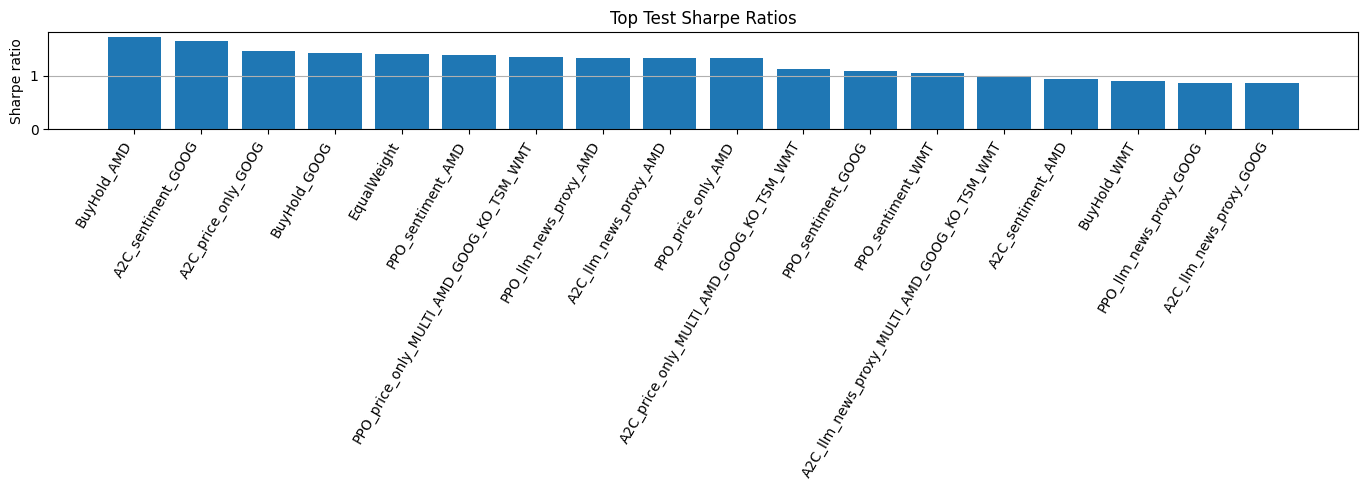

Saved: outputs\finrl_deepseek_clean_rl\figures\max_drawdown_top_models.png


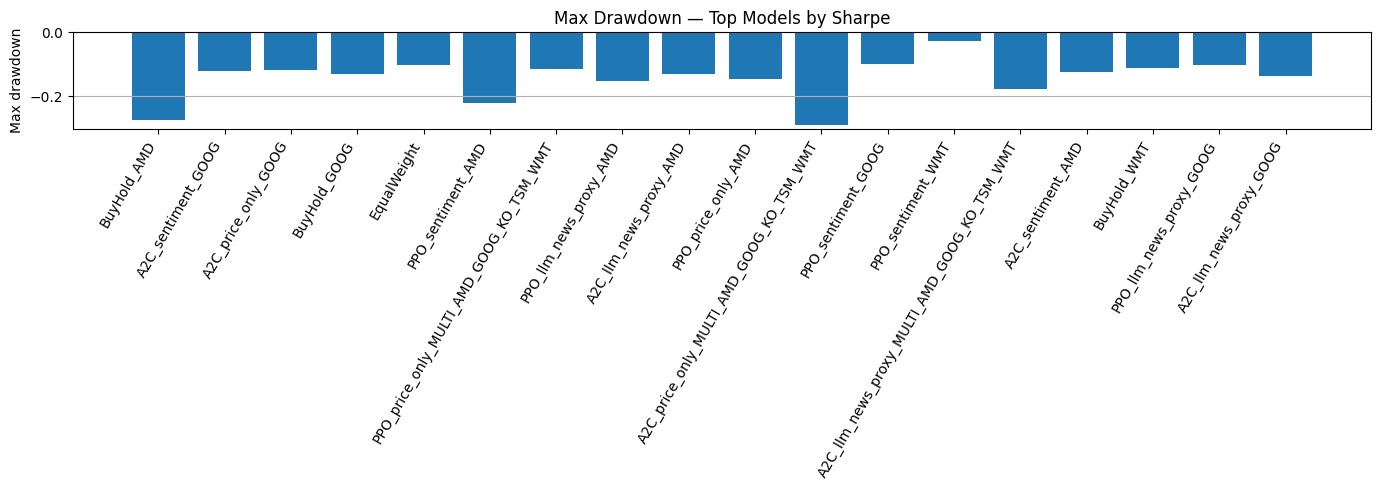

Saved: outputs\finrl_deepseek_clean_rl\figures\single_stock_equity_curves.png


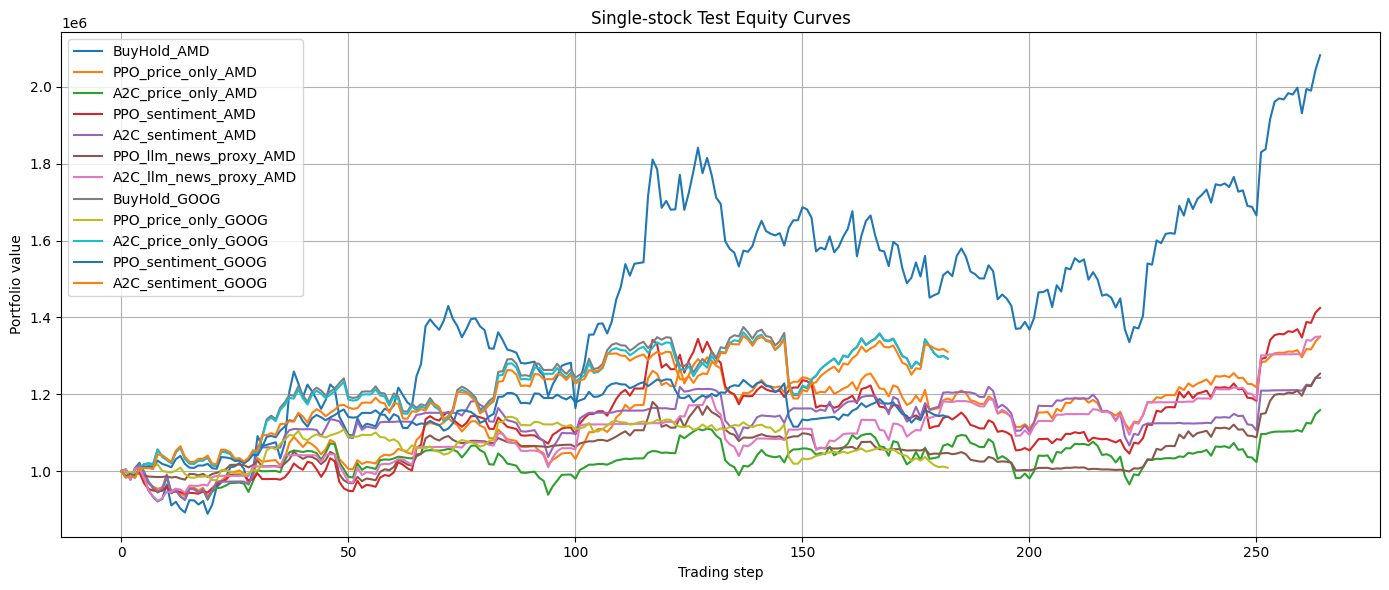

Saved: outputs\finrl_deepseek_clean_rl\figures\multi_stock_equity_curves.png


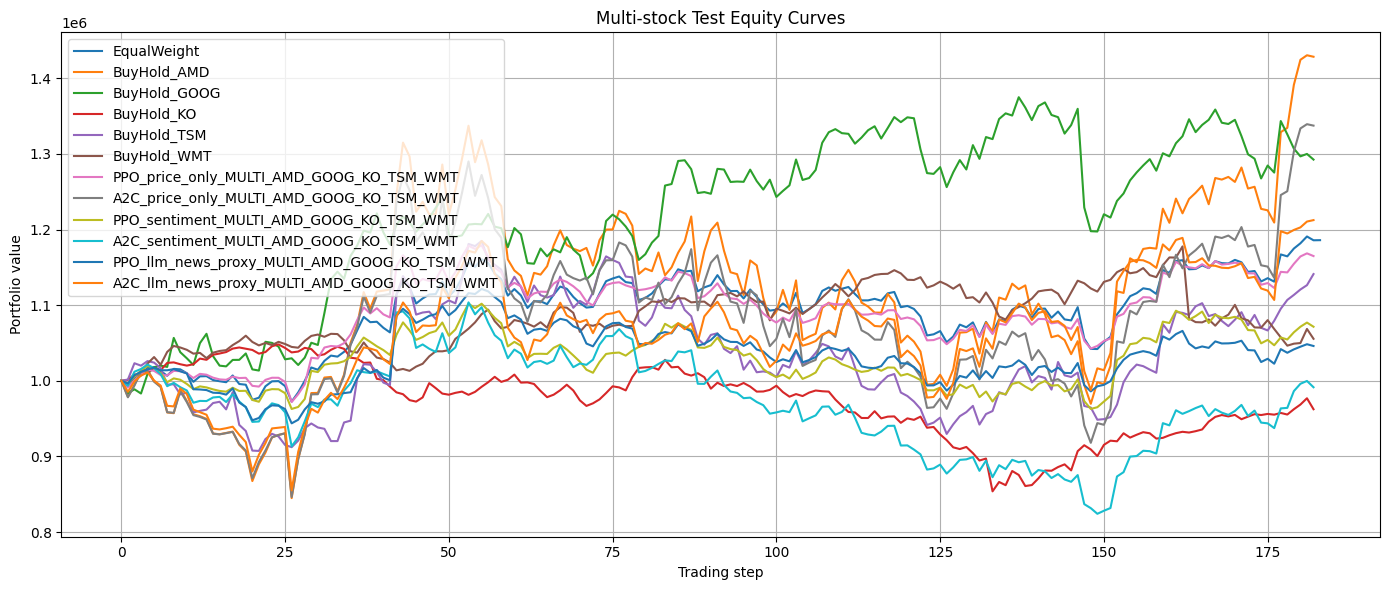

In [18]:
def plot_top_sharpe(results_df: pd.DataFrame, top_n: int = 20, out_path: Optional[Path] = None):
    if results_df.empty:
        print("No results to plot.")
        return

    plot_df = results_df.dropna(subset=["sharpe"]).sort_values("sharpe", ascending=False).head(top_n).copy()
    labels = plot_df["model"].astype(str)

    plt.figure(figsize=(14, 5))
    plt.bar(labels, plot_df["sharpe"])
    plt.xticks(rotation=60, ha="right")
    plt.ylabel("Sharpe ratio")
    plt.title("Top Test Sharpe Ratios")
    plt.grid(axis="y")
    plt.tight_layout()

    if out_path:
        plt.savefig(out_path, dpi=200, bbox_inches="tight")
        print(f"Saved: {out_path}")

    plt.show()


def plot_equity_curves(equity_curves: Dict[str, pd.Series], title: str, out_path: Optional[Path] = None, max_curves: int = 12):
    if not equity_curves:
        print("No equity curves to plot.")
        return

    plt.figure(figsize=(14, 6))
    for i, (name, values) in enumerate(equity_curves.items()):
        if i >= max_curves:
            break
        plt.plot(pd.Series(values).values, label=name)

    plt.title(title)
    plt.xlabel("Trading step")
    plt.ylabel("Portfolio value")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()

    if out_path:
        plt.savefig(out_path, dpi=200, bbox_inches="tight")
        print(f"Saved: {out_path}")

    plt.show()


def plot_drawdowns(results_df: pd.DataFrame, top_n: int = 20, out_path: Optional[Path] = None):
    if results_df.empty:
        print("No results to plot.")
        return

    plot_df = results_df.dropna(subset=["sharpe"]).sort_values("sharpe", ascending=False).head(top_n).copy()
    labels = plot_df["model"].astype(str)

    plt.figure(figsize=(14, 5))
    plt.bar(labels, plot_df["max_drawdown"])
    plt.xticks(rotation=60, ha="right")
    plt.ylabel("Max drawdown")
    plt.title("Max Drawdown — Top Models by Sharpe")
    plt.grid(axis="y")
    plt.tight_layout()

    if out_path:
        plt.savefig(out_path, dpi=200, bbox_inches="tight")
        print(f"Saved: {out_path}")

    plt.show()


if not all_results.empty:
    plot_top_sharpe(all_results, out_path=OUT / "figures" / "top_sharpe_ratios.png")
    plot_drawdowns(all_results, out_path=OUT / "figures" / "max_drawdown_top_models.png")

if single_equity:
    plot_equity_curves(single_equity, "Single-stock Test Equity Curves", out_path=OUT / "figures" / "single_stock_equity_curves.png")

if multi_equity:
    plot_equity_curves(multi_equity, "Multi-stock Test Equity Curves", out_path=OUT / "figures" / "multi_stock_equity_curves.png")

Saved: outputs\finrl_deepseek_clean_rl\figures\weights_A2C_sentiment_GOOG.png


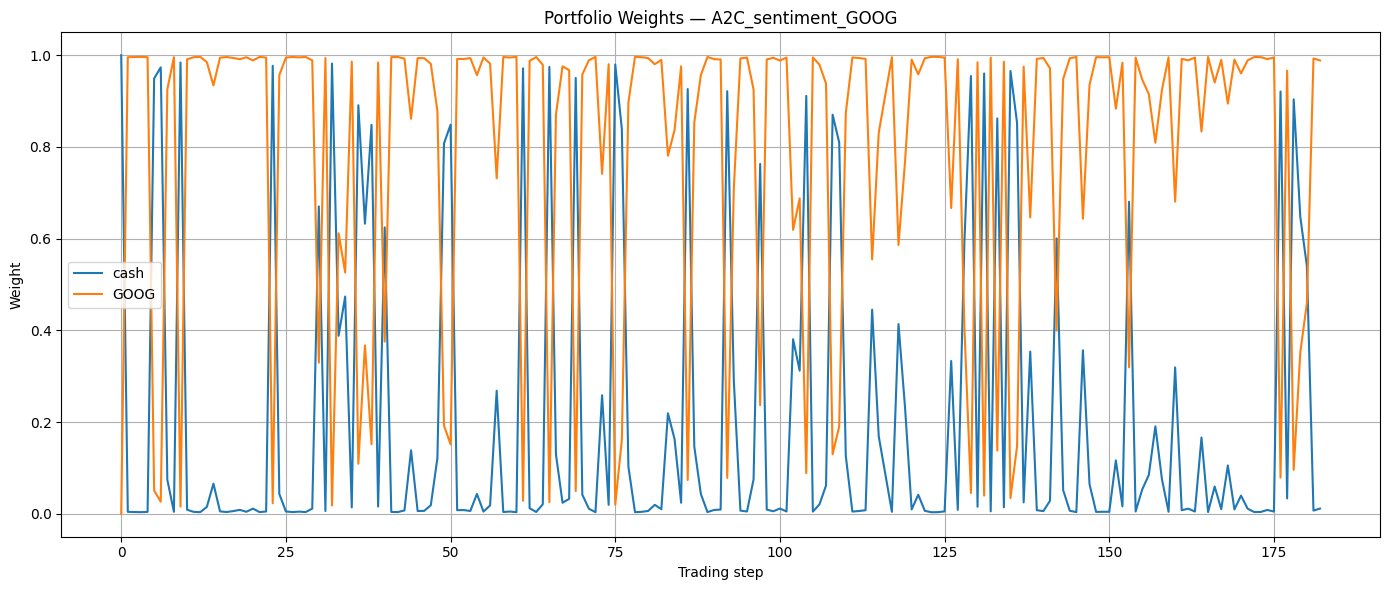

In [19]:
def plot_weights(weights_df: pd.DataFrame, title: str, out_path: Optional[Path] = None):
    if weights_df is None or weights_df.empty:
        print("No weights to plot.")
        return

    plot_df = weights_df.copy()
    cols = [c for c in plot_df.columns if c != "date"]
    x = np.arange(len(plot_df))

    plt.figure(figsize=(14, 6))
    for c in cols:
        plt.plot(x, plot_df[c].values, label=c)

    plt.title(title)
    plt.xlabel("Trading step")
    plt.ylabel("Weight")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()

    if out_path:
        plt.savefig(out_path, dpi=200, bbox_inches="tight")
        print(f"Saved: {out_path}")

    plt.show()


all_weights = {}
all_weights.update(single_weights)
all_weights.update(multi_weights)

if not all_results.empty and all_weights:
    rl_rows = all_results[all_results["algorithm"].isin(CFG["rl_algorithms"])].dropna(subset=["sharpe"]).copy()
    if not rl_rows.empty:
        best_model_name = rl_rows.sort_values("sharpe", ascending=False).iloc[0]["model"]
        if best_model_name in all_weights:
            plot_weights(
                all_weights[best_model_name],
                f"Portfolio Weights — {best_model_name}",
                out_path=OUT / "figures" / f"weights_{best_model_name}.png",
            )
        else:
            print(f"No weights found for best model: {best_model_name}")

## 14. Optional: real structured LLM scoring cache

The current notebook uses `sentiment_gpt` from the processed FNSPID pipeline and turns it into structured proxy variables.

For a stronger contribution, you can later generate a true structured LLM cache from raw news text.

Recommended output schema per news item:

```json
{
  "sentiment": -1.0,
  "relevance": 0.8,
  "risk": 0.3,
  "uncertainty": 0.2,
  "event_type": "earnings",
  "impact_horizon": "short"
}
```

Then aggregate by `date, tic` and merge into the panel.
The environment already accepts the resulting columns if you name them:

- `llm_signal_decay`
- `llm_risk_decay`
- `llm_uncertainty_decay`
- `news_count`
- `news_flag`

In [20]:
STRUCTURED_LLM_PROMPT = (
    "You are a financial news analyst. Analyze the news item for the specified stock ticker.\n\n"
    "Return valid JSON only with these fields:\n"
    "- sentiment: number in [-1, 1], where -1 is very negative, 0 neutral, 1 very positive.\n"
    "- relevance: number in [0, 1], relevance of the news to the ticker.\n"
    "- risk: number in [0, 1], whether the news increases downside risk.\n"
    "- uncertainty: number in [0, 1], uncertainty about the market impact.\n"
    "- event_type: one of ['earnings', 'guidance', 'analyst_rating', 'product', 'legal_regulatory', 'macro', 'ma', 'management', 'other'].\n"
    "- impact_horizon: one of ['intraday', 'short', 'medium', 'long'].\n\n"
    "Ticker: {ticker}\n"
    "News date: {date}\n"
    "News text:\n{text}\n"
)

print(STRUCTURED_LLM_PROMPT[:900])

You are a financial news analyst. Analyze the news item for the specified stock ticker.

Return valid JSON only with these fields:
- sentiment: number in [-1, 1], where -1 is very negative, 0 neutral, 1 very positive.
- relevance: number in [0, 1], relevance of the news to the ticker.
- risk: number in [0, 1], whether the news increases downside risk.
- uncertainty: number in [0, 1], uncertainty about the market impact.
- event_type: one of ['earnings', 'guidance', 'analyst_rating', 'product', 'legal_regulatory', 'macro', 'ma', 'management', 'other'].
- impact_horizon: one of ['intraday', 'short', 'medium', 'long'].

Ticker: {ticker}
News date: {date}
News text:
{text}



## 15. Paper-ready summary text

In [21]:
if not all_results.empty:
    best = all_results.dropna(subset=["sharpe"]).sort_values("sharpe", ascending=False).iloc[0]
    print("Best model by Sharpe:")
    display(best.to_frame().T)

    summary = (
        "\nExperimental summary:\n"
        "- We evaluate RL trading agents on a cleaned FNSPID price-news panel.\n"
        "- We first run single-stock experiments to avoid losing history through multi-asset date intersection.\n"
        "- We then run a strictly filtered multi-stock portfolio experiment.\n"
        f"- The best model in this run is {best['model']} with Sharpe={best['sharpe']:.3f}, "
        f"cumulative return={best['cumulative_return']:.3f}, and max drawdown={best['max_drawdown']:.3f}.\n"
        "- Results should be considered final only when run_profile='paper' and test sets have sufficient length.\n"
    )
    print(summary)
else:
    print("No result summary available yet.")

Best model by Sharpe:


,scope,ticker_group,model,algorithm,feature_set,final_value,cumulative_return,annualized_return,annualized_volatility,sharpe,max_drawdown,calmar,avg_turnover,n_steps
0,single_stock,AMD,BuyHold_AMD,BuyHold,baseline,2082549.309885,1.082549,1.014251,0.468529,1.727282,-0.274944,3.68894,0.0,265



Experimental summary:
- We evaluate RL trading agents on a cleaned FNSPID price-news panel.
- We first run single-stock experiments to avoid losing history through multi-asset date intersection.
- We then run a strictly filtered multi-stock portfolio experiment.
- The best model in this run is BuyHold_AMD with Sharpe=1.727, cumulative return=1.083, and max drawdown=-0.275.
- Results should be considered final only when run_profile='paper' and test sets have sufficient length.



## 16. Sanity checklist before using results in the paper

Before writing final conclusions, verify:

1. every test set has enough days, ideally at least 150 trading days;
2. the `llm_news_proxy` columns are not zero everywhere;
3. transaction costs are enabled;
4. baselines are included;
5. the same chronological split is used for all variants;
6. feature scaling is fitted only on the training split;
7. random seeds are fixed;
8. final results are produced with `run_profile="paper"`;
9. single-stock and multi-stock results are reported separately.

Safe claim:

> LLM-derived news signals can improve risk-adjusted performance in selected settings, but their benefit depends on the ticker, test period, and trading costs.